In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib
import os

In [2]:
df = pd.read_csv("../dataset/student_data.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# First 5 rows
df.head()

Dataset Shape: (6607, 20)

Columns:
Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='str')

Data Types:
Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence         

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [5]:
# Fill missing values in categorical columns

categorical_columns = [
    "Teacher_Quality",
    "Parental_Education_Level",
    "Distance_from_Home"
]

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing Values After Filling:")
print(df.isnull().sum())

Missing Values After Filling:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [6]:
print(df.dtypes)

Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
Exam_Score                    int64
dtype: object


In [7]:
print(df["Teacher_Quality"].unique())
print(df["Parental_Education_Level"].unique())
print(df["Distance_from_Home"].unique())

<ArrowStringArray>
['Medium', 'High', 'Low', nan]
Length: 4, dtype: str
<ArrowStringArray>
['High School', 'College', 'Postgraduate', nan]
Length: 4, dtype: str
<ArrowStringArray>
['Near', 'Moderate', 'Far', nan]
Length: 4, dtype: str


In [8]:
# Fill missing values using the most frequent value (mode)

for col in ["Teacher_Quality",
            "Parental_Education_Level",
            "Distance_from_Home"]:
    mode_value = df[col].mode(dropna=True)[0]
    df[col] = df[col].fillna(mode_value)

print(df.isnull().sum())

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6607 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [41]:
df = df.drop_duplicates()

In [43]:
# Dataset shape after removing duplicates

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (6607, 20)


In [42]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count == 0:
    print("No duplicate records found.")
else:
    print("Duplicate records found and will be removed.")

Number of duplicate rows: 0
No duplicate records found.


In [11]:
df.to_csv("../dataset/student_data_cleaned.csv", index=False)

print("Dataset saved successfully.")

Dataset saved successfully.


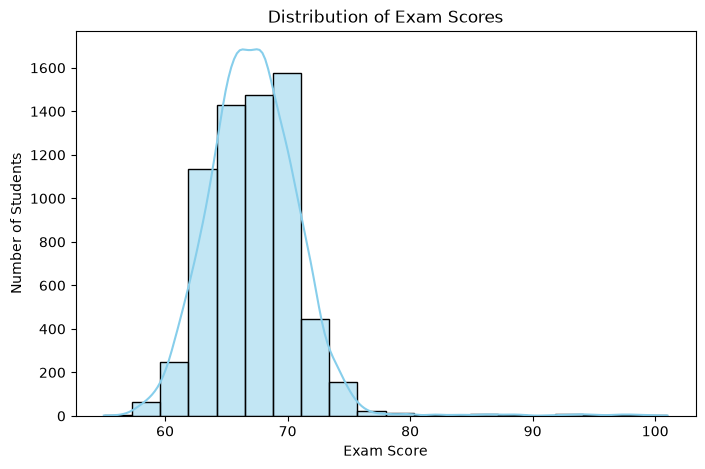

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["Exam_Score"], bins=20, kde=True, color="skyblue")

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()

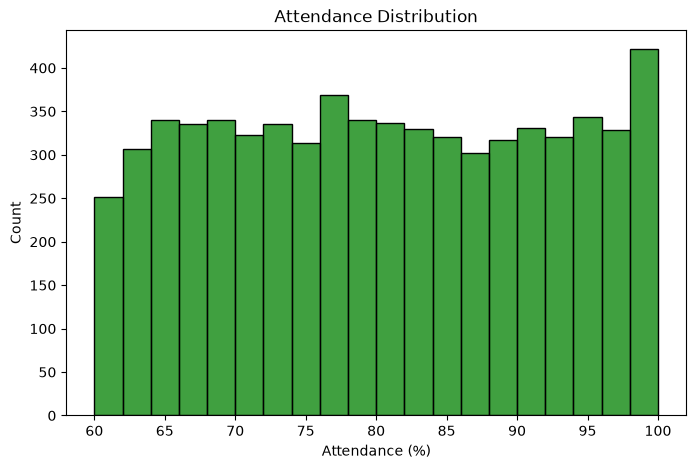

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["Attendance"], bins=20, color="green")

plt.title("Attendance Distribution")
plt.xlabel("Attendance (%)")

plt.show()

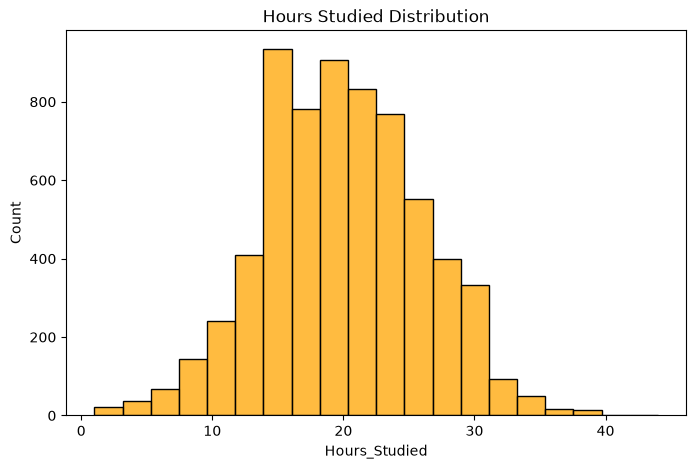

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["Hours_Studied"], bins=20, color="orange")

plt.title("Hours Studied Distribution")

plt.show()

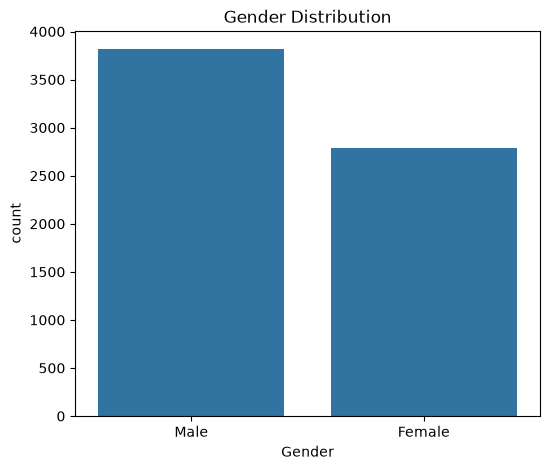

In [15]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Gender")

plt.title("Gender Distribution")

plt.show()

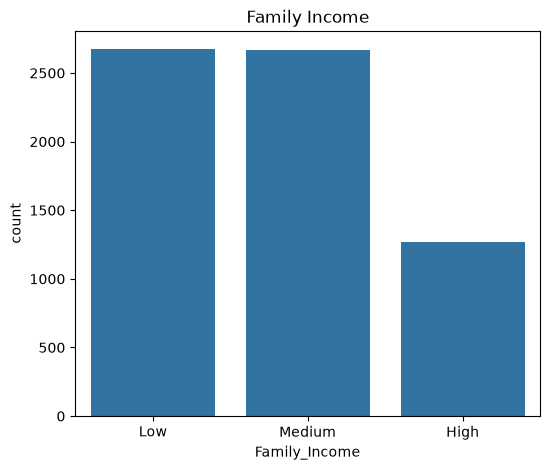

In [16]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Family_Income")

plt.title("Family Income")

plt.show()

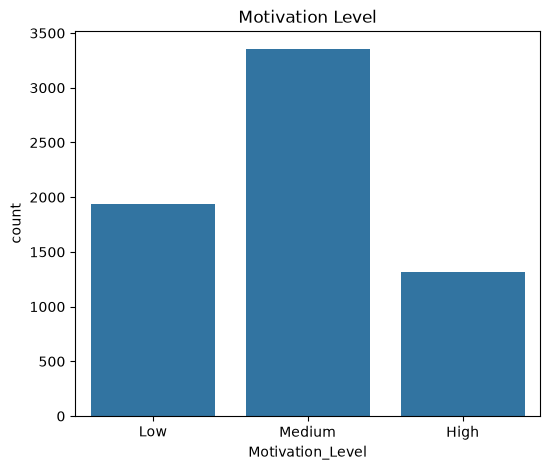

In [17]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Motivation_Level")

plt.title("Motivation Level")

plt.show()

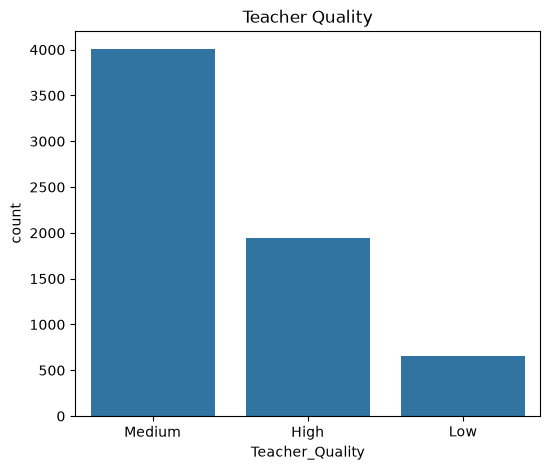

In [18]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Teacher_Quality")

plt.title("Teacher Quality")

plt.show()

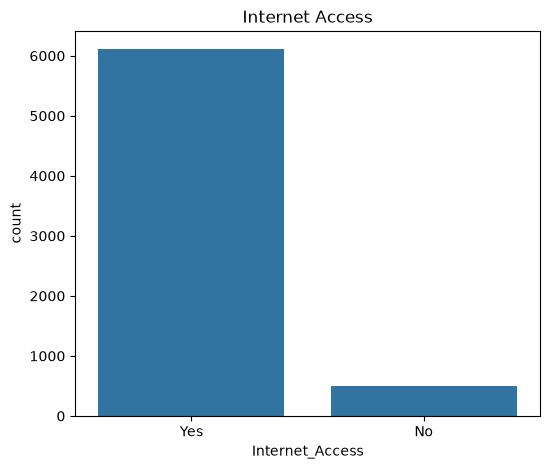

In [19]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Internet_Access")

plt.title("Internet Access")

plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

encoder = LabelEncoder()

for col in df_encoded.select_dtypes(include=["object", "string"]).columns:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])

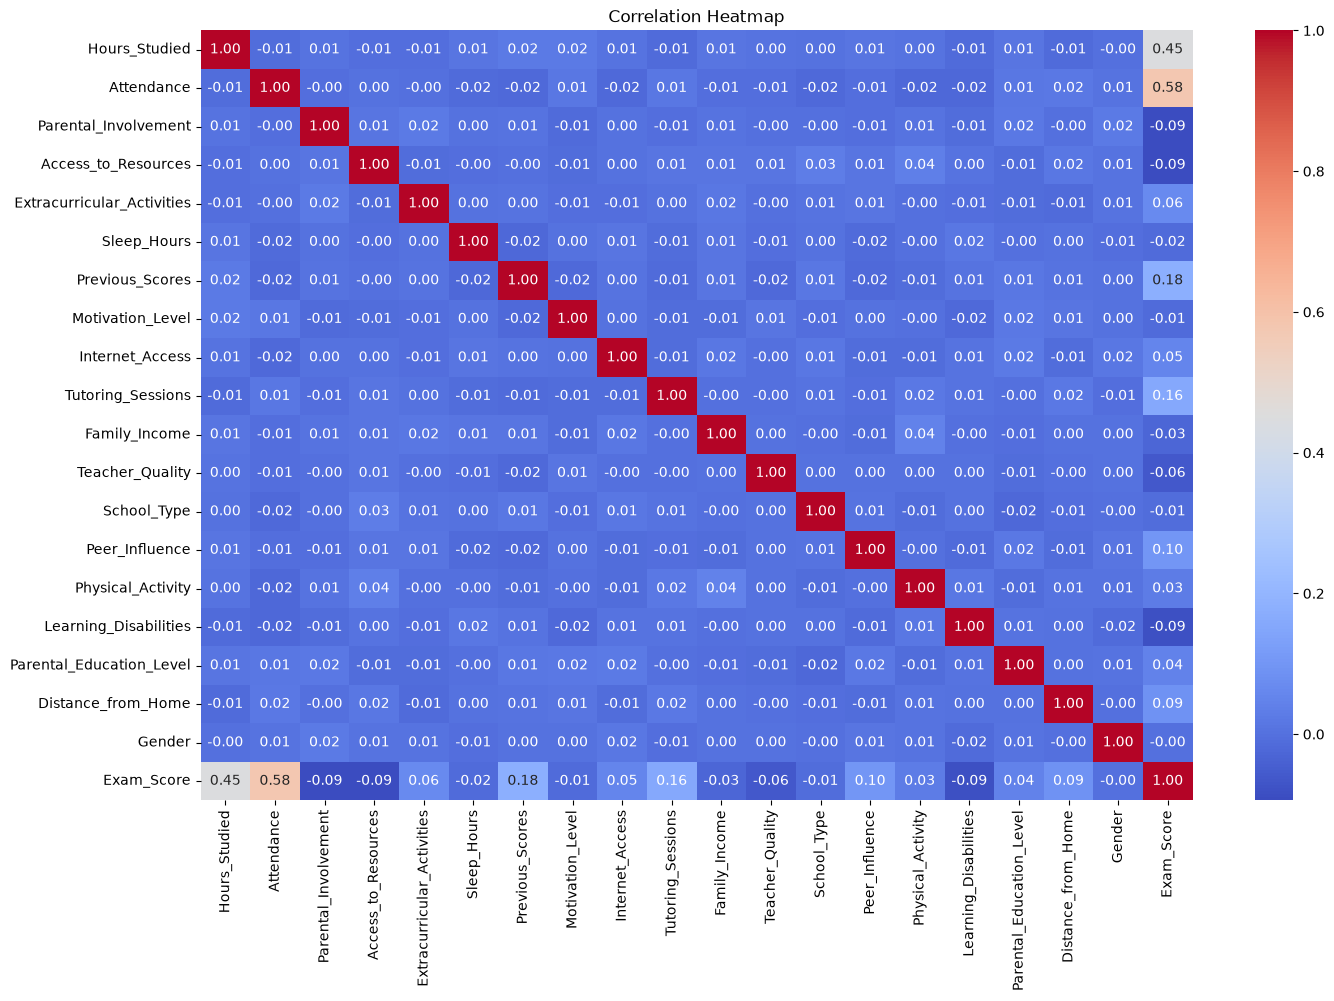

In [21]:
plt.figure(figsize=(16,10))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [22]:
def performance(score):
    if score >= 70:
        return "High"
    elif score >= 60:
        return "Average"
    else:
        return "Low"

df_encoded["Performance"] = df_encoded["Exam_Score"].apply(performance)

df_encoded[["Exam_Score", "Performance"]].head()

,Exam_Score,Performance
0,67,Average
1,61,Average
2,74,High
3,71,High
4,70,High


In [23]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

df_encoded["Performance"] = target_encoder.fit_transform(df_encoded["Performance"])

print(target_encoder.classes_)

['Average' 'High' 'Low']


In [24]:
X = df_encoded.drop(["Exam_Score", "Performance"], axis=1)

y = df_encoded["Performance"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [26]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [28]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [29]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score

results = {
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "KNN": accuracy_score(y_test, knn_pred)
}

for model, accuracy in results.items():
    print(f"{model}: {accuracy:.4f}")

Decision Tree: 0.8464
Random Forest: 0.8986
Logistic Regression: 0.8949
KNN: 0.8601


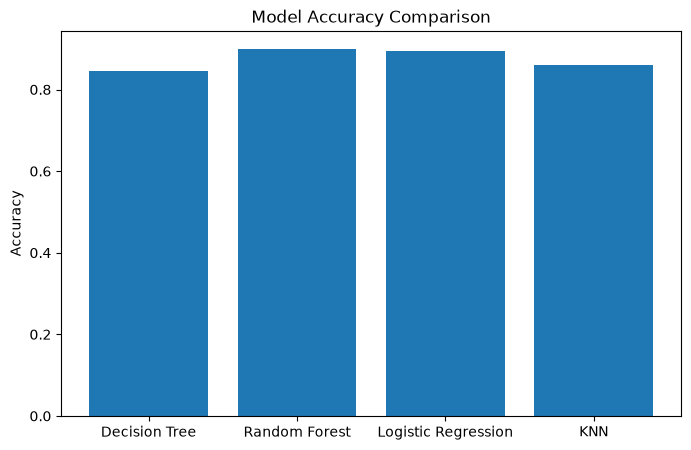

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results.keys(), results.values())

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [32]:
import joblib
import os

os.makedirs("../model", exist_ok=True)

joblib.dump(rf_model, "../model/student_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


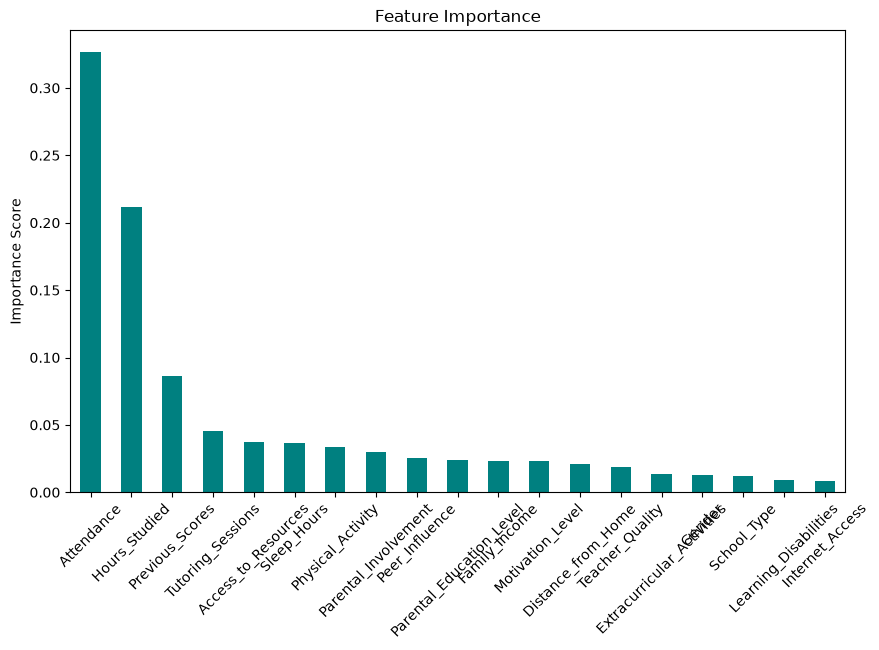

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.plot(kind="bar", color="teal")

plt.title("Feature Importance")

plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.show()

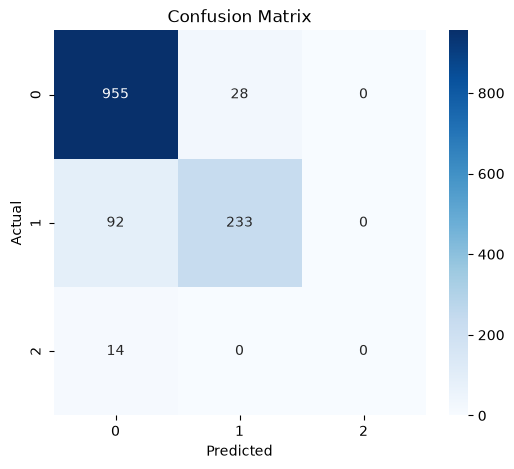

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.90      0.97      0.93       983
           1       0.89      0.72      0.80       325
           2       0.00      0.00      0.00        14

    accuracy                           0.90      1322
   macro avg       0.60      0.56      0.58      1322
weighted avg       0.89      0.90      0.89      1322



In [36]:
from sklearn.preprocessing import LabelEncoder
import joblib

encoders = {}

for col in df.select_dtypes(include=["object", "string"]).columns:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col].astype(str))
    encoders[col] = encoder

joblib.dump(encoders, "../model/label_encoders.pkl")

print("Encoders Saved Successfully!")

Encoders Saved Successfully!


In [37]:
import joblib

model = joblib.load("../model/student_model.pkl")

print("Model loaded successfully!")
print("Model classes:", model.classes_)

Model loaded successfully!
Model classes: [0 1 2]


In [38]:
print(model.classes_)

[0 1 2]


In [39]:
import joblib

# Load the saved label encoders
encoders = joblib.load("../model/label_encoders.pkl")

print("Encoders loaded successfully!")
print("Encoded columns:")
print(list(encoders.keys()))

Encoders loaded successfully!
Encoded columns:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [40]:
print("Model features:")
print(model.feature_names_in_)

print("\nNumber of features:")
print(len(model.feature_names_in_))

Model features:
['Hours_Studied' 'Attendance' 'Parental_Involvement' 'Access_to_Resources'
 'Extracurricular_Activities' 'Sleep_Hours' 'Previous_Scores'
 'Motivation_Level' 'Internet_Access' 'Tutoring_Sessions' 'Family_Income'
 'Teacher_Quality' 'School_Type' 'Peer_Influence' 'Physical_Activity'
 'Learning_Disabilities' 'Parental_Education_Level' 'Distance_from_Home'
 'Gender']

Number of features:
19


In [44]:
# Descriptive Statistics for Numerical Features

df.describe()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
count,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,1.220070,1.203421,0.596035,7.02906,75.070531,1.307553,0.924474,1.493719,1.211442,1.311185,0.695929,1.190858,2.967610,0.105191,0.896473,1.498411,0.577267,67.235659
std,5.990594,11.547475,0.865634,0.871783,0.490728,1.46812,14.399784,0.782515,0.264258,1.230570,0.742264,0.896574,0.460048,0.755876,1.031231,0.306823,0.698511,0.670260,0.494031,3.890456
min,1.000000,60.000000,0.000000,0.000000,0.000000,4.00000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,0.000000,0.000000,0.000000,6.00000,63.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,1.000000,0.000000,65.000000
50%,20.000000,80.000000,2.000000,2.000000,1.000000,7.00000,75.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,3.000000,0.000000,1.000000,2.000000,1.000000,67.000000
75%,24.000000,90.000000,2.000000,2.000000,1.000000,8.00000,88.000000,2.000000,1.000000,2.000000,2.000000,2.000000,1.000000,2.000000,4.000000,0.000000,1.000000,2.000000,1.000000,69.000000
max,44.000000,100.000000,2.000000,2.000000,1.000000,10.00000,100.000000,2.000000,1.000000,8.000000,2.000000,2.000000,1.000000,2.000000,6.000000,1.000000,2.000000,2.000000,1.000000,101.000000


In [47]:
# Frequency summary of categorical features

categorical_columns = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Extracurricular_Activities",
    "Motivation_Level",
    "Internet_Access",
    "Family_Income",
    "Teacher_Quality",
    "School_Type",
    "Peer_Influence",
    "Learning_Disabilities",
    "Parental_Education_Level",
    "Distance_from_Home",
    "Gender"
]

for column in categorical_columns:
    print("\n" + "=" * 50)
    print(column)
    print(df[column].value_counts().sort_index())


Parental_Involvement
Parental_Involvement
0    1908
1    1337
2    3362
Name: count, dtype: int64

Access_to_Resources
Access_to_Resources
0    1975
1    1313
2    3319
Name: count, dtype: int64

Extracurricular_Activities
Extracurricular_Activities
0    2669
1    3938
Name: count, dtype: int64

Motivation_Level
Motivation_Level
0    1319
1    1937
2    3351
Name: count, dtype: int64

Internet_Access
Internet_Access
0     499
1    6108
Name: count, dtype: int64

Family_Income
Family_Income
0    1269
1    2672
2    2666
Name: count, dtype: int64

Teacher_Quality
Teacher_Quality
0    1947
1     657
2    4003
Name: count, dtype: int64

School_Type
School_Type
0    2009
1    4598
Name: count, dtype: int64

Peer_Influence
Peer_Influence
0    1377
1    2592
2    2638
Name: count, dtype: int64

Learning_Disabilities
Learning_Disabilities
0    5912
1     695
Name: count, dtype: int64

Parental_Education_Level
Parental_Education_Level
0    1989
1    3313
2    1305
Name: count, dtype: int64

Di

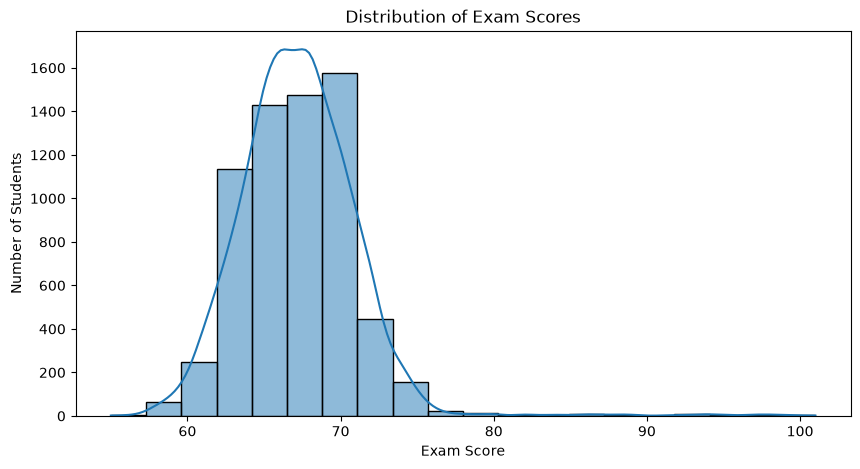

In [48]:
# Distribution of Exam Scores

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(
    df["Exam_Score"],
    bins=20,
    kde=True
)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()

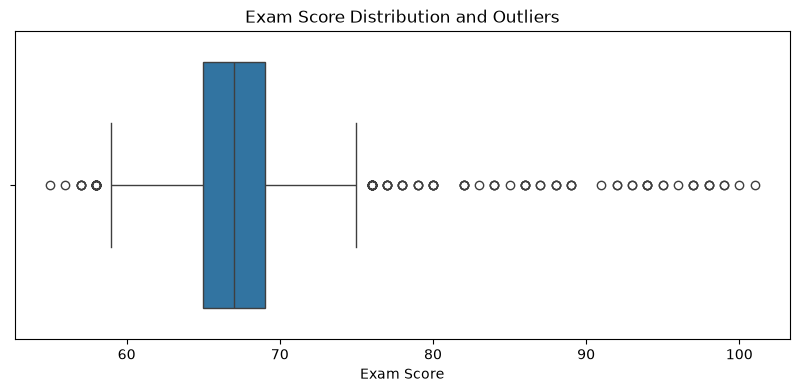

In [49]:
# Boxplot of Exam Scores

plt.figure(figsize=(10, 4))

sns.boxplot(x=df["Exam_Score"])

plt.title("Exam Score Distribution and Outliers")
plt.xlabel("Exam Score")

plt.show()

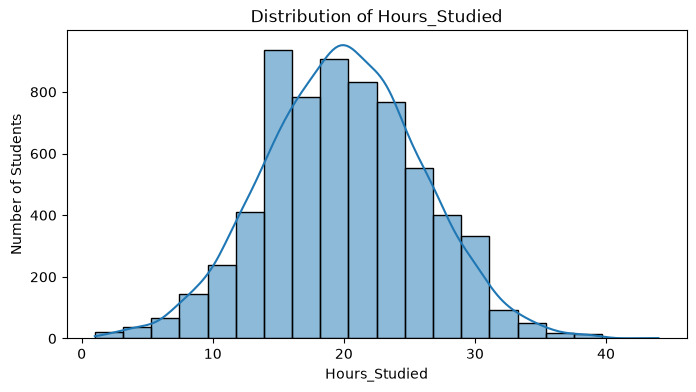

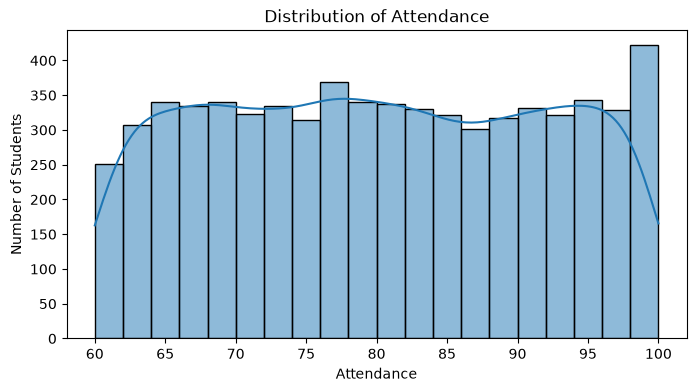

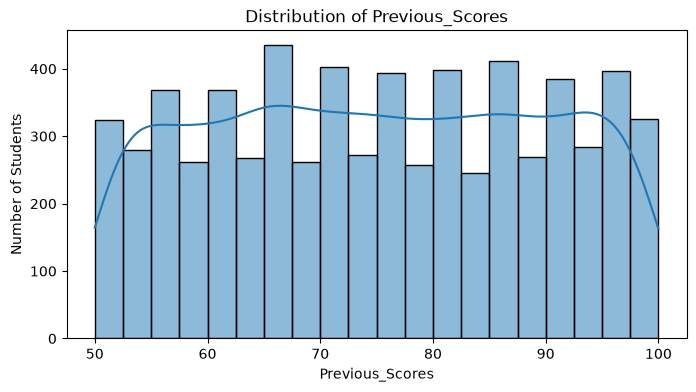

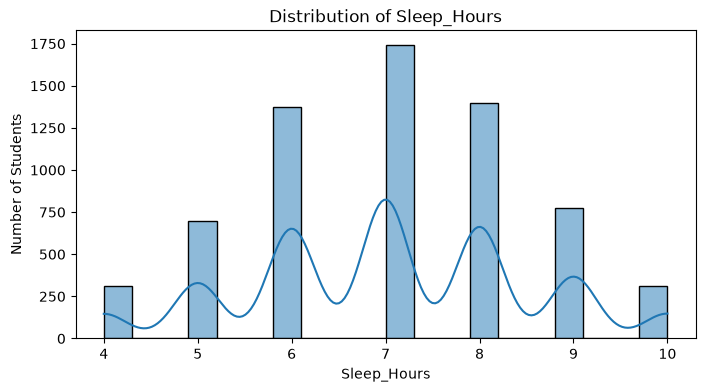

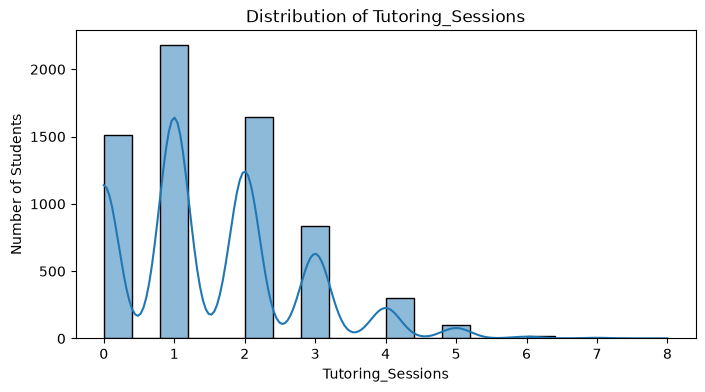

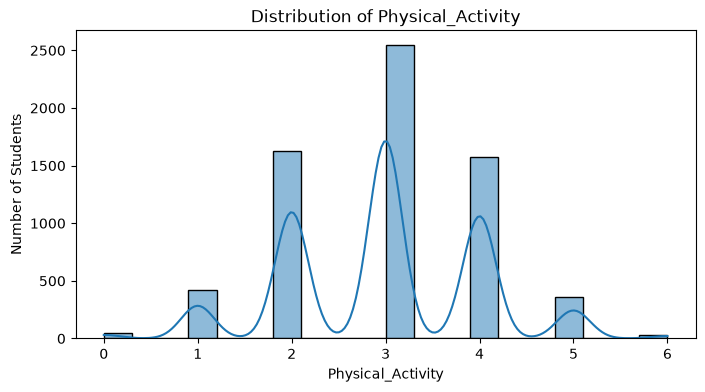

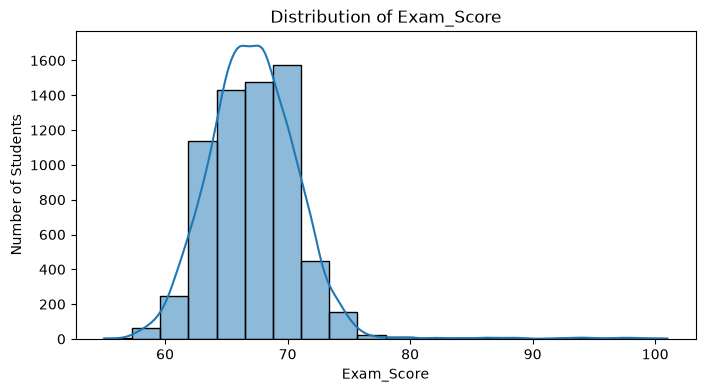

In [50]:
# Distribution of Numerical Features

numerical_columns = [
    "Hours_Studied",
    "Attendance",
    "Previous_Scores",
    "Sleep_Hours",
    "Tutoring_Sessions",
    "Physical_Activity",
    "Exam_Score"
]

for column in numerical_columns:

    plt.figure(figsize=(8, 4))

    sns.histplot(
        df[column],
        bins=20,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Students")

    plt.show()

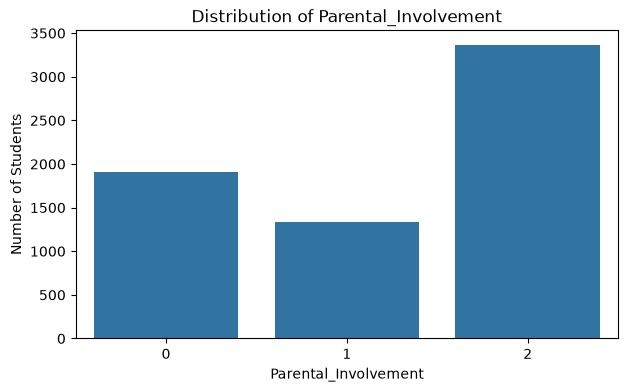

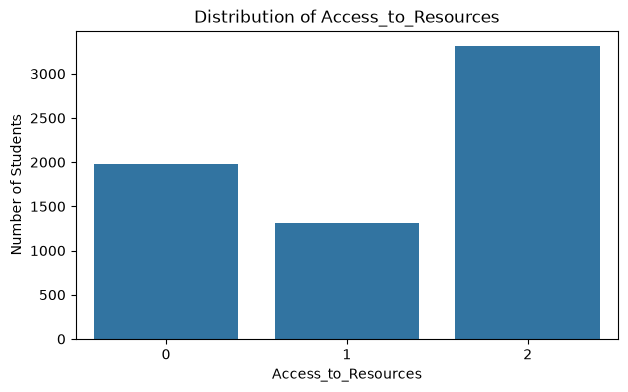

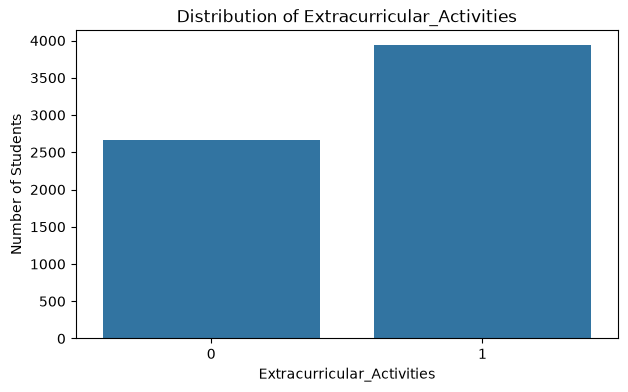

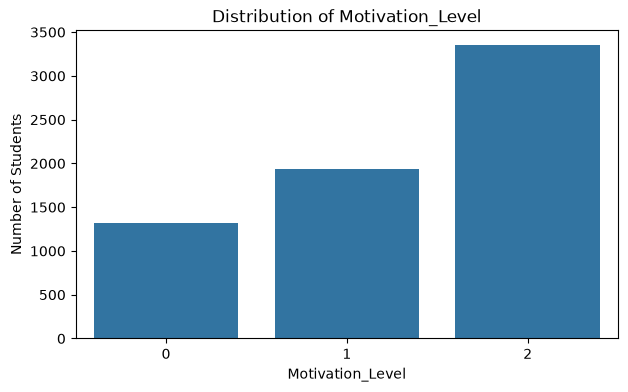

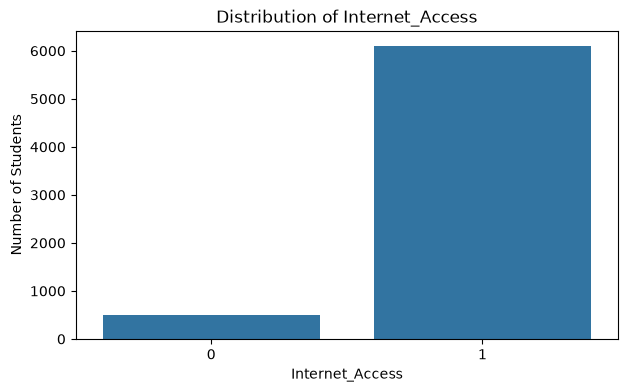

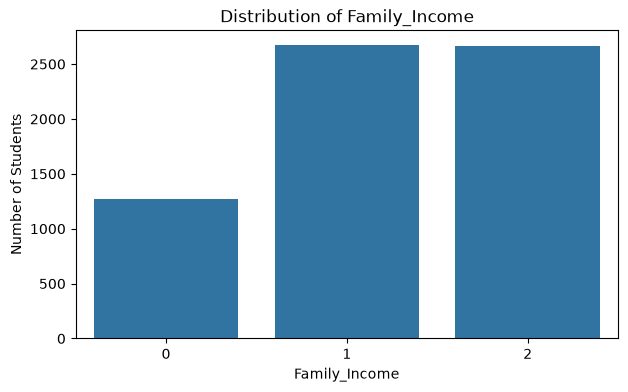

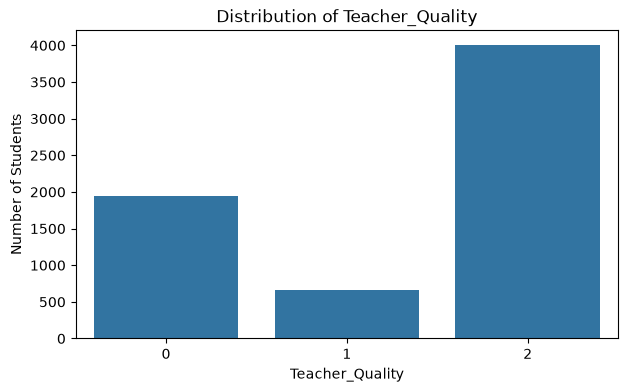

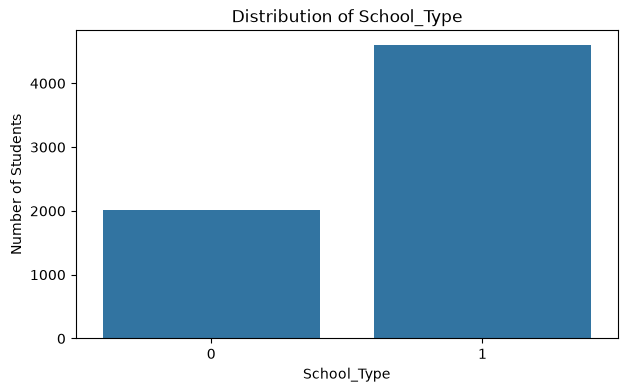

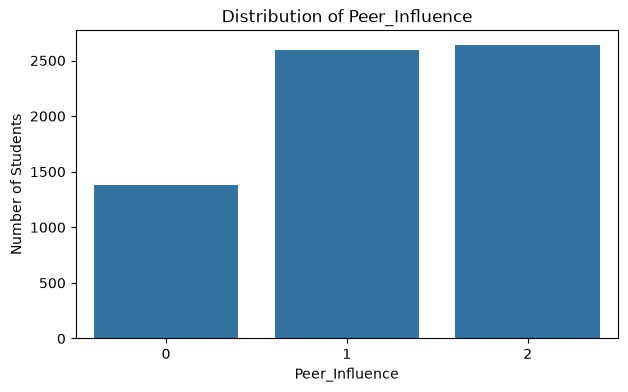

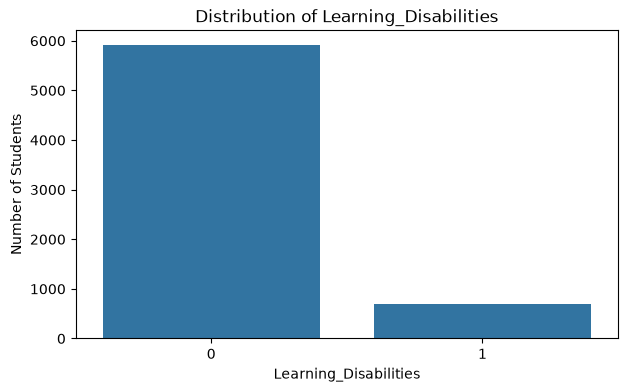

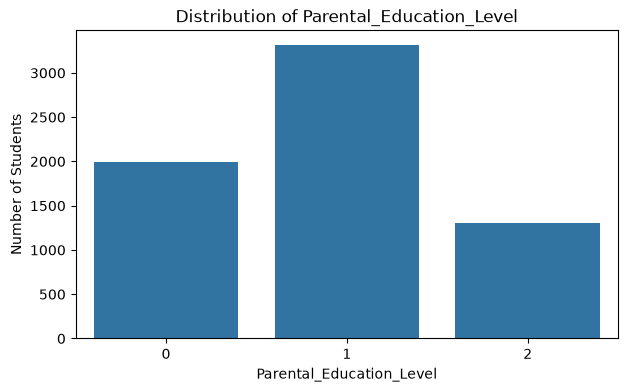

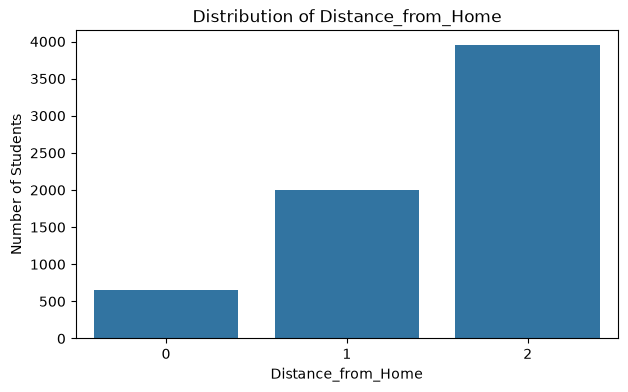

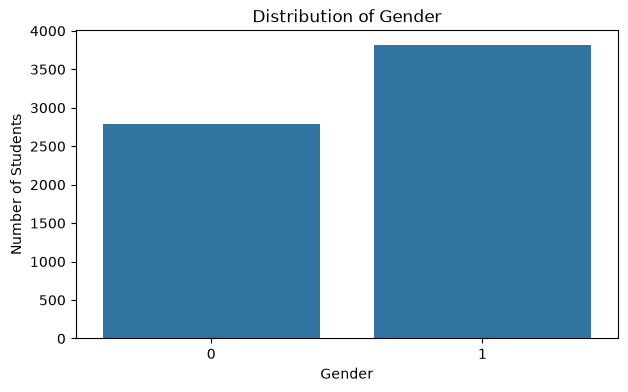

In [51]:
# Distribution of Categorical Features

for column in categorical_columns:

    plt.figure(figsize=(7, 4))

    sns.countplot(
        x=df[column]
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Students")

    plt.show()

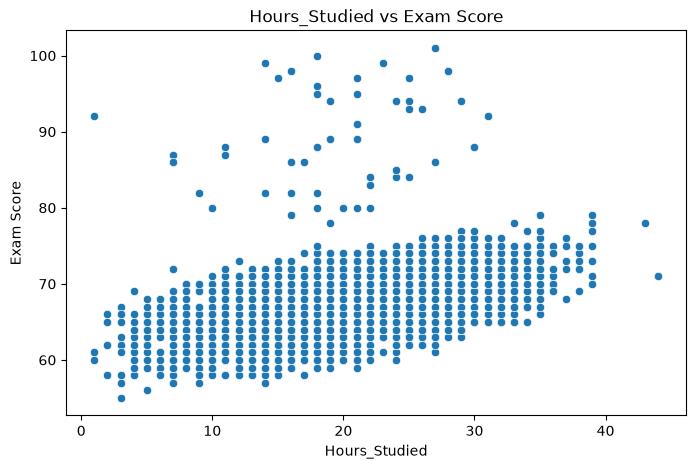

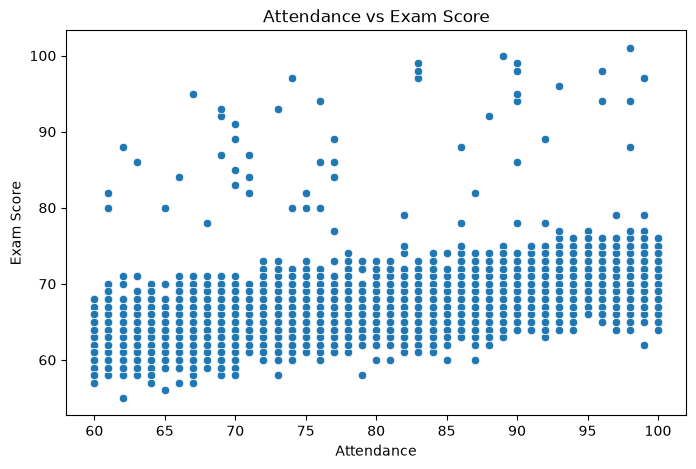

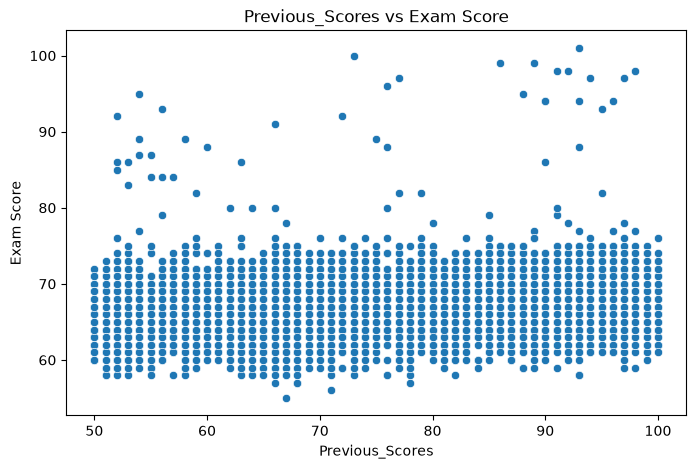

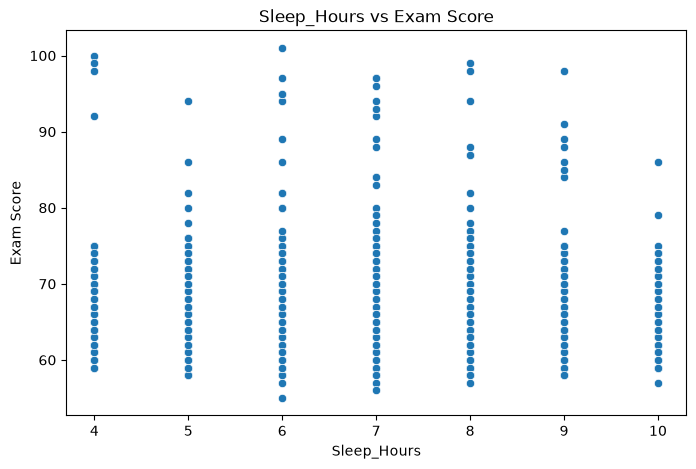

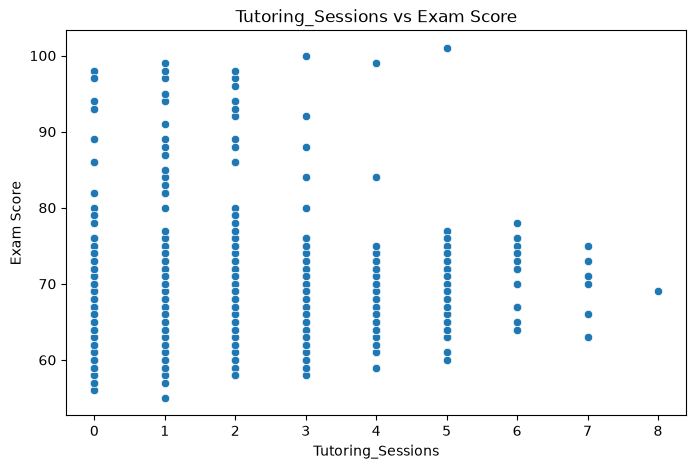

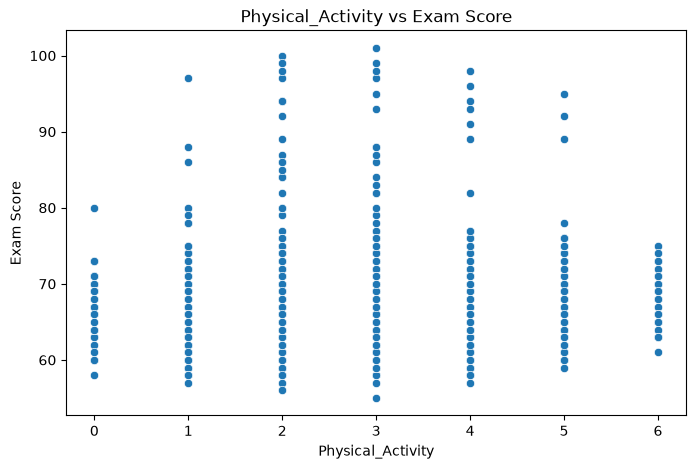

In [52]:
# Relationship between Numerical Features and Exam Score

numerical_features = [
    "Hours_Studied",
    "Attendance",
    "Previous_Scores",
    "Sleep_Hours",
    "Tutoring_Sessions",
    "Physical_Activity"
]

for column in numerical_features:

    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        x=df[column],
        y=df["Exam_Score"]
    )

    plt.title(f"{column} vs Exam Score")
    plt.xlabel(column)
    plt.ylabel("Exam Score")

    plt.show()

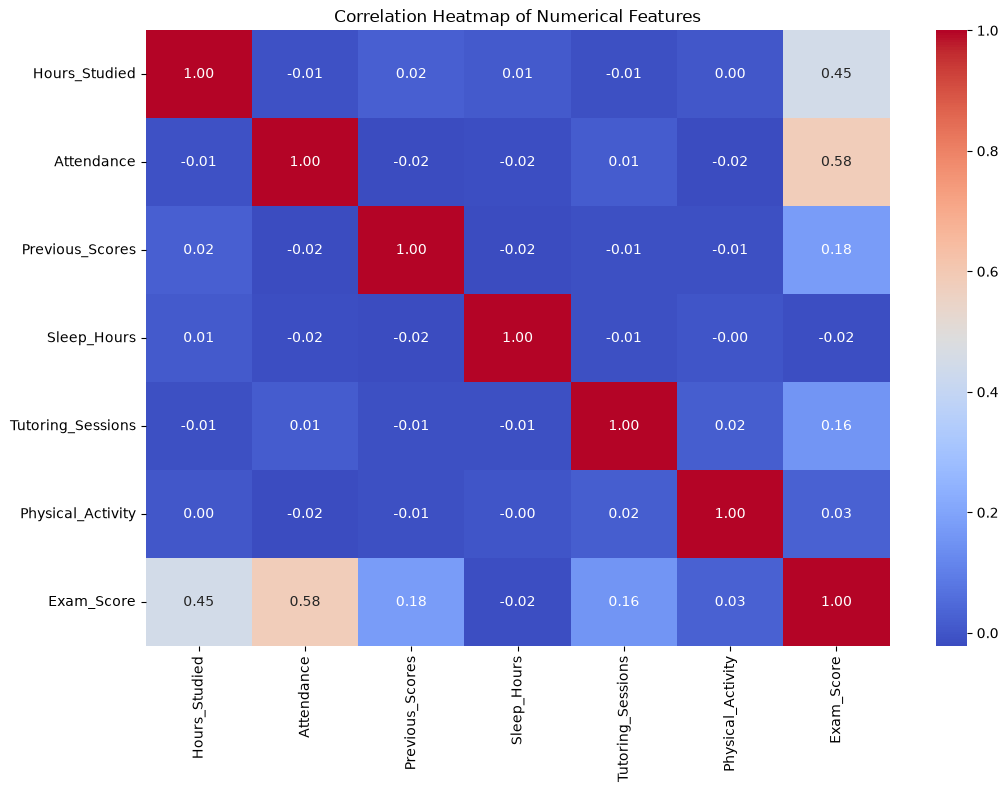

In [53]:
# Correlation Heatmap

plt.figure(figsize=(12, 8))

correlation = df[numerical_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

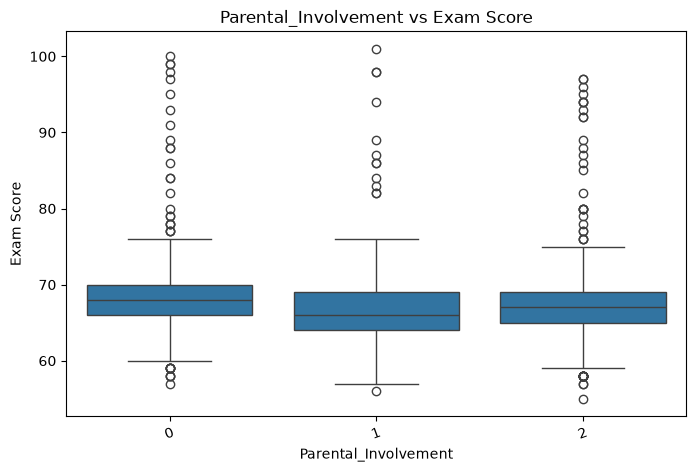

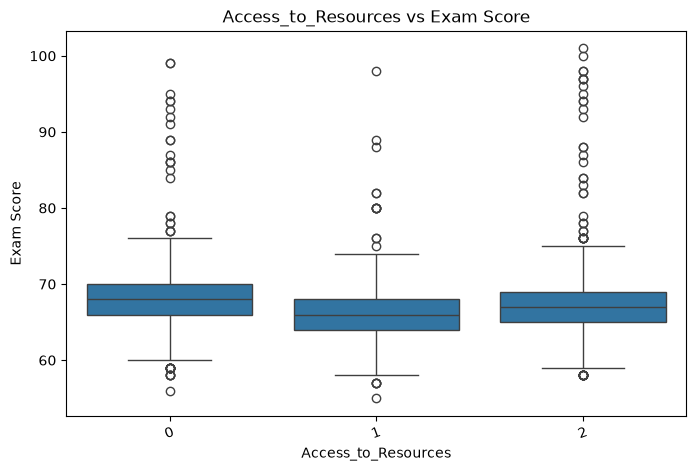

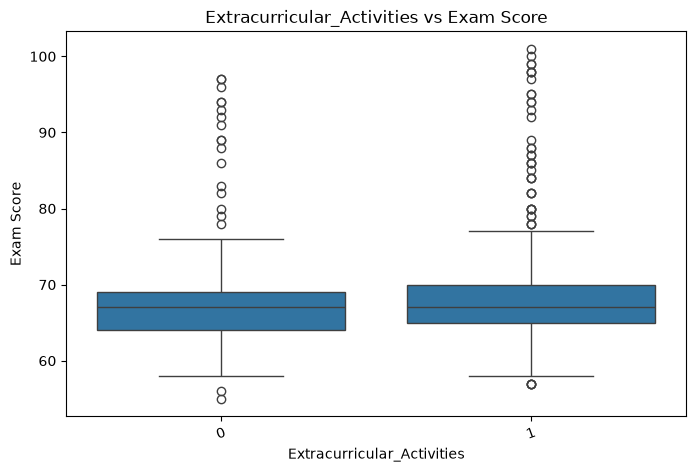

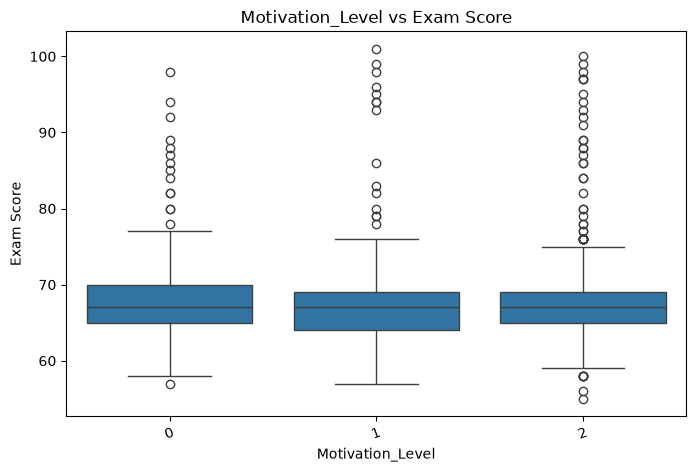

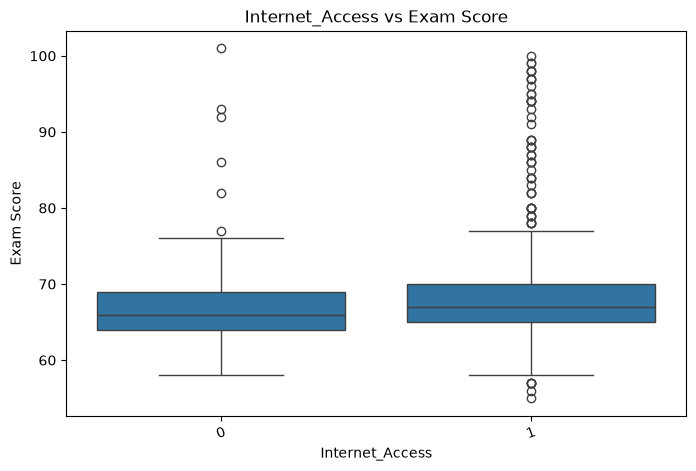

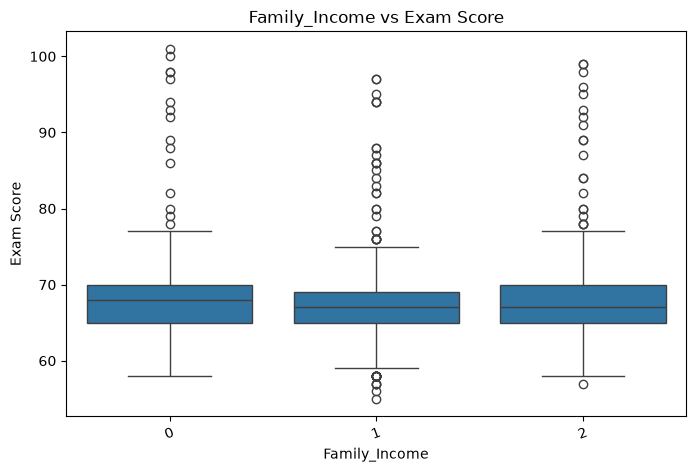

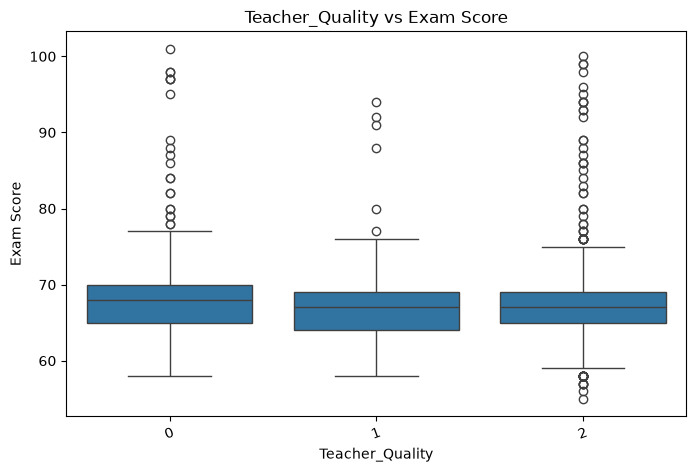

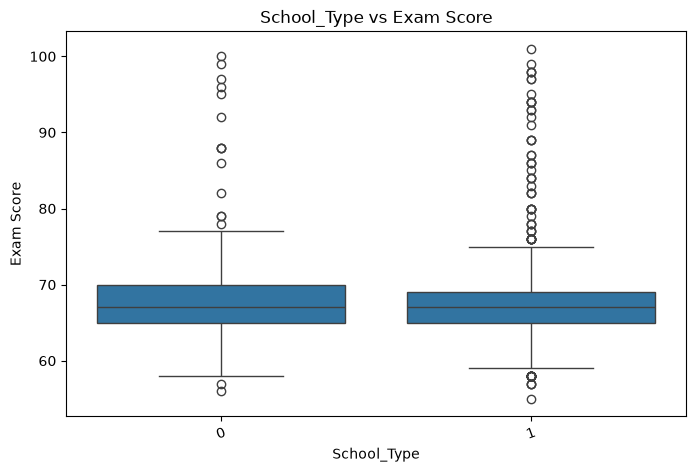

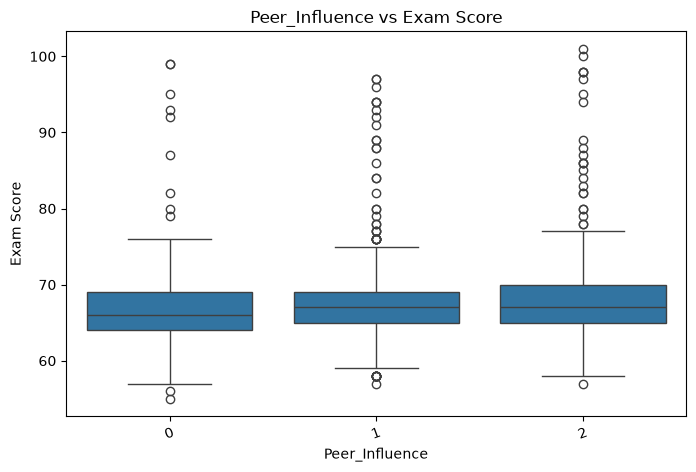

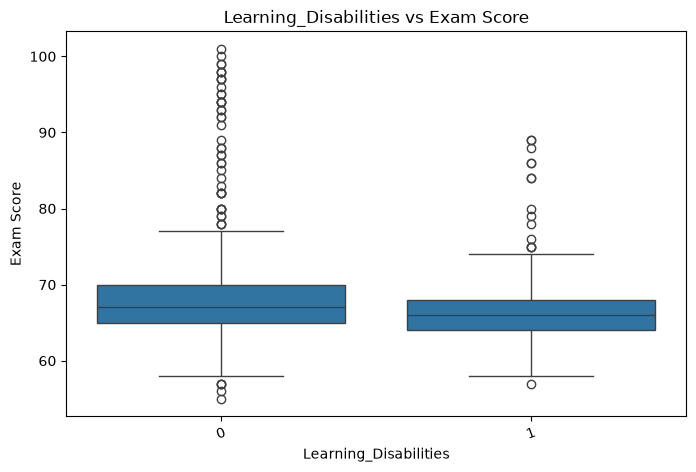

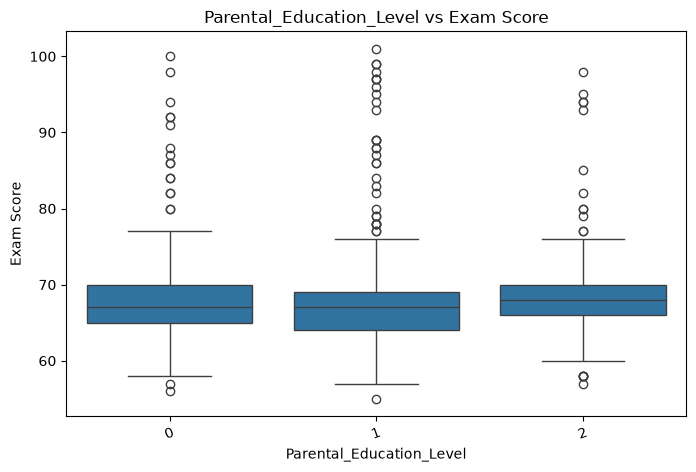

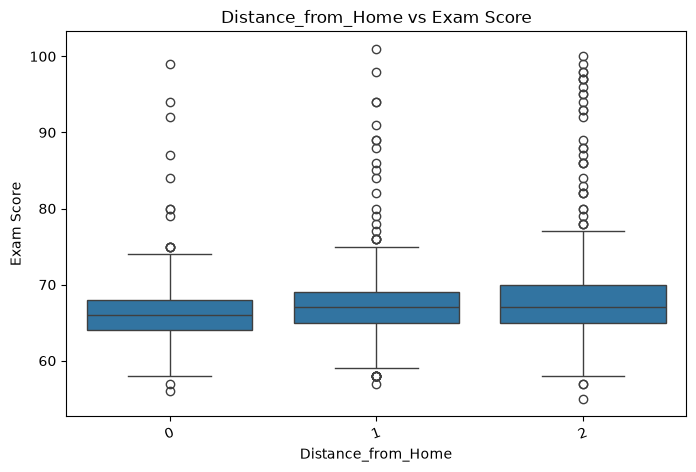

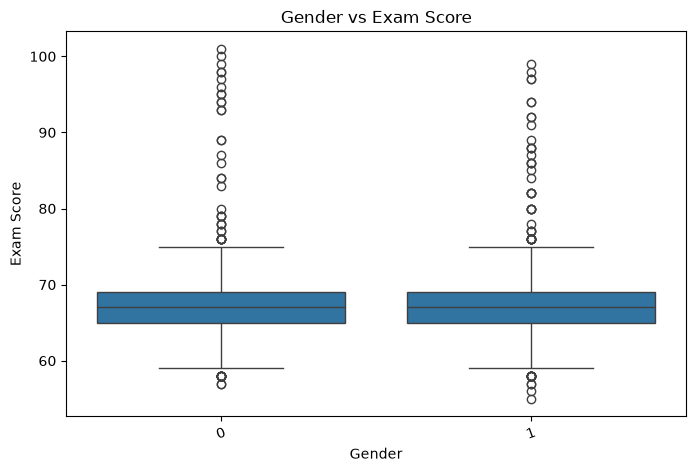

In [54]:
# Categorical Features vs Exam Score

for column in categorical_columns:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        x=df[column],
        y=df["Exam_Score"]
    )

    plt.title(f"{column} vs Exam Score")
    plt.xlabel(column)
    plt.ylabel("Exam Score")

    plt.xticks(rotation=20)
    plt.show()

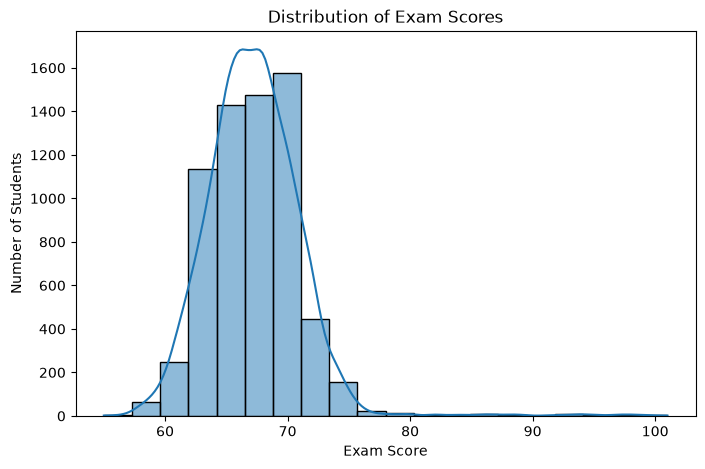

In [55]:
# Exam Score Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Exam_Score"],
    bins=20,
    kde=True
)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()

In [56]:
# Exam Score Statistics

print("Exam Score Statistics")
print("-" * 30)

print("Mean:", df["Exam_Score"].mean())
print("Median:", df["Exam_Score"].median())
print("Minimum:", df["Exam_Score"].min())
print("Maximum:", df["Exam_Score"].max())
print("Standard Deviation:", df["Exam_Score"].std())

Exam Score Statistics
------------------------------
Mean: 67.23565914938702
Median: 67.0
Minimum: 55
Maximum: 101
Standard Deviation: 3.890455781261732


In [57]:
# Create Performance Classes

def performance(score):
    if score >= 70:
        return "High"
    elif score >= 60:
        return "Average"
    else:
        return "Low"

df["Performance"] = df["Exam_Score"].apply(performance)

print(df[["Exam_Score", "Performance"]].head())

   Exam_Score Performance
0          67     Average
1          61     Average
2          74        High
3          71        High
4          70        High


Performance
Average    4914
High       1625
Low          68
Name: count, dtype: int64


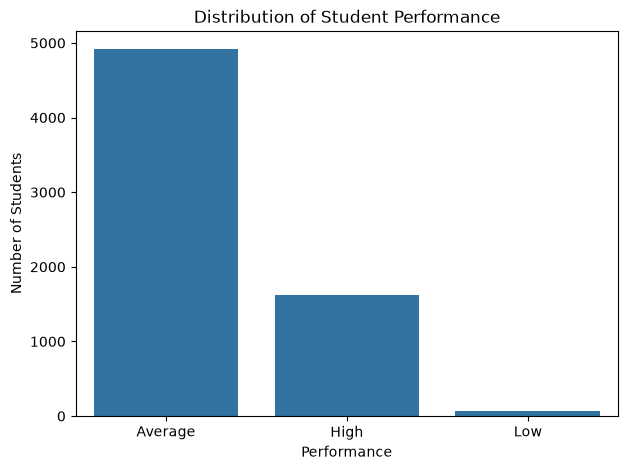

In [58]:
# Performance Class Distribution

print(df["Performance"].value_counts())

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Performance"
)

plt.title("Distribution of Student Performance")
plt.xlabel("Performance")
plt.ylabel("Number of Students")

plt.show()


In [59]:
# Separate Features and Target

X = df.drop(["Exam_Score", "Performance"], axis=1)
y = df["Performance"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (6607, 19)
Target shape: (6607,)


In [60]:
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()

encoders = {}

for column in X_encoded.select_dtypes(include="object").columns:

    encoder = LabelEncoder()

    X_encoded[column] = encoder.fit_transform(
        X_encoded[column].astype(str)
    )

    encoders[column] = encoder

print("Categorical features encoded successfully.")
print("Encoded features shape:", X_encoded.shape)

Categorical features encoded successfully.
Encoded features shape: (6607, 19)


In [61]:
# Encode Target Variable

target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(y)

print("Target classes:", target_encoder.classes_)

Target classes: ['Average' 'High' 'Low']


In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5285, 19)
Testing data: (1322, 19)
